In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import statsmodels.api as sm
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Data Loading & Cleaning

Load BTC and ETH Kalshi prediction market CSVs, parse timestamps, and decode Market Tickers into structured fields (asset, date, contract open time, price threshold). Then audit data quality across four dimensions: missing values, probability sum consistency, duplicate timestamps, and contract length. We flag—but do not drop—anomalous contracts using an `is_clean` boolean column.

In [14]:
btc = pd.read_csv("data/kalshi_btc_prices.csv", parse_dates=["Timestamp"])
eth = pd.read_csv("data/kalshi_eth_prices.csv", parse_dates=["Timestamp"])

# Ticker format: KX{ASSET}15M-{YY}{MON}{DD}{HHMM}-{THRESHOLD}
# e.g. KXBTC15M-26FEB161830-30 → BTC, Feb 16 2026, 18:30, threshold $30
month_map = {'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
             'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12}

def parse_ticker(ticker):
    m = re.match(r'KX(BTC|ETH)15M-(\d{2})([A-Z]{3})(\d{2})(\d{4})-(\d+)', ticker)
    if m:
        year  = int(m.group(2)) + 2000
        month = month_map[m.group(3)]
        day   = int(m.group(4))
        hhmm  = m.group(5)
        return (m.group(1),
                pd.Timestamp(year=year, month=month, day=day),
                f"{hhmm[:2]}:{hhmm[2:]}",
                int(m.group(6)))
    return None, None, None, None

for df in [btc, eth]:
    parsed = df['Market Ticker'].apply(parse_ticker)
    df['asset']              = parsed.apply(lambda x: x[0])
    df['contract_date']      = parsed.apply(lambda x: x[1])
    df['contract_time']      = parsed.apply(lambda x: x[2])
    df['price_threshold']    = parsed.apply(lambda x: x[3])
    df['minute_in_contract'] = df.groupby('Market Ticker').cumcount()

print(f"BTC: {len(btc):,} rows | {btc['Market Ticker'].nunique()} contracts")
print(f"ETH: {len(eth):,} rows | {eth['Market Ticker'].nunique()} contracts")
btc.head(3)

BTC: 33,951 rows | 2264 contracts
ETH: 29,136 rows | 1943 contracts


,Timestamp,P(UP),P(DOWN),Momentum,Prediction,Actual Outcome,Correct?,Market Ticker,Volume,asset,contract_date,contract_time,price_threshold,minute_in_contract
0,2026-02-16 15:15:00,0.4800,0.5200,0.0000,DOWN,DOWN,Correct,KXBTC15M-26FEB161830-30,143697.0,BTC,2026-02-16,18:30,30,0
1,2026-02-16 15:16:00,0.5283,0.4717,0.0483,UP,DOWN,Incorrect,KXBTC15M-26FEB161830-30,143697.0,BTC,2026-02-16,18:30,30,1
2,2026-02-16 15:17:00,0.6717,0.3283,0.1434,UP,DOWN,Incorrect,KXBTC15M-26FEB161830-30,143697.0,BTC,2026-02-16,18:30,30,2


In [15]:
for name, df in [('BTC', btc), ('ETH', eth)]:
    print(f"\n{'='*45}\n{name} Data Quality Report\n{'='*45}")

    # Missing values
    miss = df.isnull().sum()
    print("\nMissing values per column:")
    print(miss[miss > 0].to_string() if miss.any() else "  none")

    # P(UP) + P(DOWN) sum
    bad_prob = ((df['P(UP)'] + df['P(DOWN)'] - 1).abs() > 0.01)
    print(f"\nRows where |P(UP)+P(DOWN)−1| > 0.01: {bad_prob.sum()}")
    if bad_prob.any():
        print(df[bad_prob][['Timestamp', 'P(UP)', 'P(DOWN)', 'Market Ticker']].head())

    # Duplicate (Timestamp, ticker) rows
    dups = df.duplicated(subset=['Timestamp', 'Market Ticker'])
    print(f"\nDuplicate (Timestamp, Market Ticker) rows: {dups.sum()}")

    # Contracts with < 15 rows
    sizes = df.groupby('Market Ticker').size()
    short = sizes[sizes < 15]
    print(f"\nContracts with < 15 rows: {len(short)} / {len(sizes)}")
    if len(short):
        print(short.to_string())


BTC Data Quality Report

Missing values per column:
Actual Outcome    6
Correct?          6
Volume            6

Rows where |P(UP)+P(DOWN)−1| > 0.01: 0

Duplicate (Timestamp, Market Ticker) rows: 0

Contracts with < 15 rows: 1 / 2264
Market Ticker
KXBTC15M-26MAR262115-15    6

ETH Data Quality Report

Missing values per column:
Actual Outcome    6
Correct?          6
Volume            6

Rows where |P(UP)+P(DOWN)−1| > 0.01: 0

Duplicate (Timestamp, Market Ticker) rows: 0

Contracts with < 15 rows: 1 / 1943
Market Ticker
KXETH15M-26MAR262115-15    6


In [16]:
def add_is_clean(df):
    prob_ok = (df['P(UP)'] + df['P(DOWN)'] - 1).abs() <= 0.01
    no_dup  = ~df.duplicated(subset=['Timestamp', 'Market Ticker'])
    size_ok = df.groupby('Market Ticker')['Timestamp'].transform('count') >= 15
    df['is_clean'] = prob_ok & no_dup & size_ok
    return df

btc = add_is_clean(btc)
eth = add_is_clean(eth)

for name, df in [('BTC', btc), ('ETH', eth)]:
    clean_contracts = df.groupby('Market Ticker')['is_clean'].all()
    print(f"{name}: {clean_contracts.sum()} / {len(clean_contracts)} contracts fully clean "
          f"({clean_contracts.mean():.1%})")

BTC: 2263 / 2264 contracts fully clean (100.0%)
ETH: 1942 / 1943 contracts fully clean (99.9%)


## 2. Exploratory Data Analysis

We examine how probability distributions shift from contract open (minute 0) to close (minute 14), plot calibration curves to assess whether P(UP) is a reliable predictor, track how accuracy evolves minute-by-minute within a contract, compute rolling volatility as a market-activity proxy, and profile volume across contracts and by hour of day.

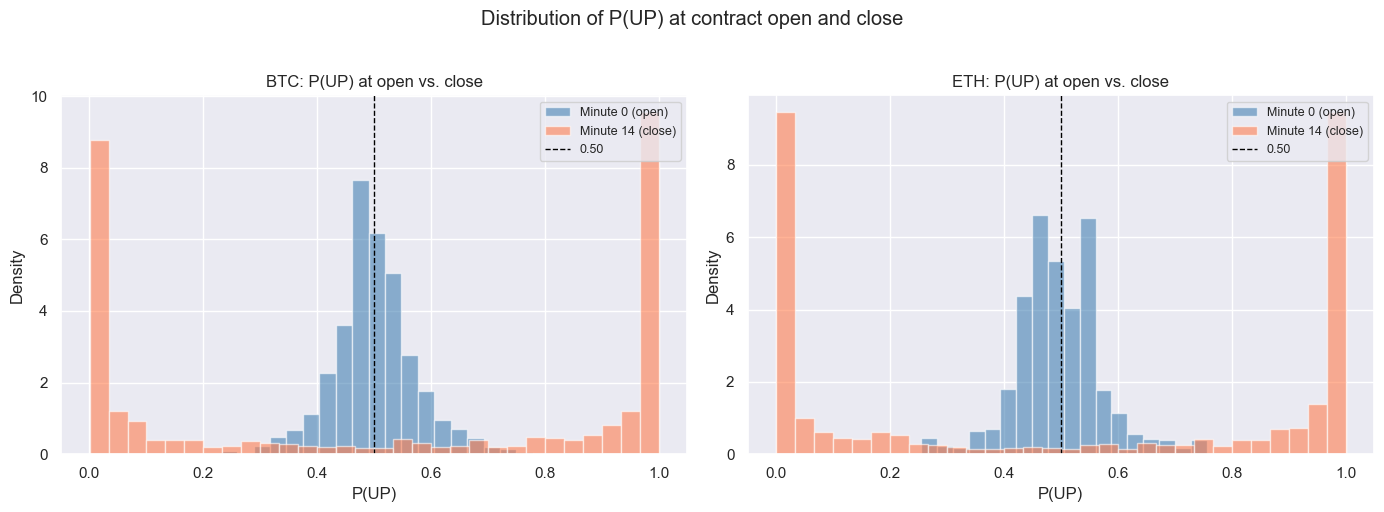

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, df) in zip(axes, [('BTC', btc), ('ETH', eth)]):
    opens  = df[df['minute_in_contract'] == 0]['P(UP)']
    closes = df[df['minute_in_contract'] == 14]['P(UP)']

    ax.hist(opens,  bins=30, alpha=0.6, density=True, label='Minute 0 (open)',   color='steelblue')
    ax.hist(closes, bins=30, alpha=0.6, density=True, label='Minute 14 (close)', color='coral')
    ax.axvline(0.5, color='black', linestyle='--', lw=1, label='0.50')
    ax.set_title(f'{name}: P(UP) at open vs. close')
    ax.set_xlabel('P(UP)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Distribution of P(UP) at contract open and close', y=1.02)
plt.tight_layout()
plt.show()

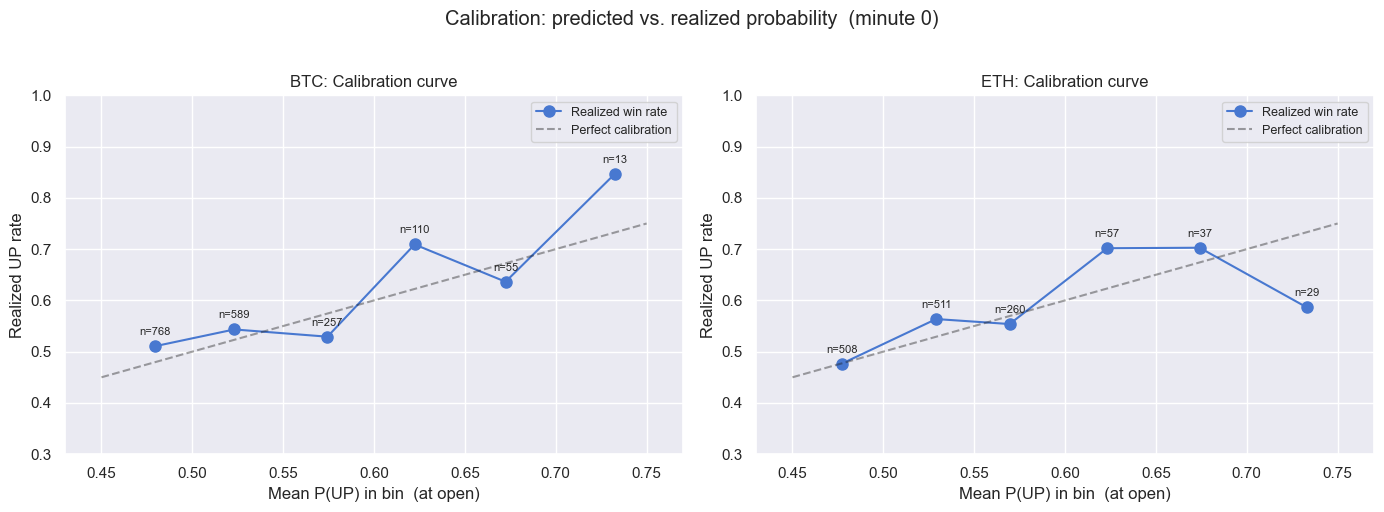

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = np.arange(0.45, 0.76, 0.05)

for ax, (name, df) in zip(axes, [('BTC', btc), ('ETH', eth)]):
    opens = df[(df['minute_in_contract'] == 0) & df['Actual Outcome'].notna()].copy()
    opens['outcome_up'] = (opens['Actual Outcome'] == 'UP').astype(int)
    opens['pup_bin']    = pd.cut(opens['P(UP)'], bins=bins)

    calib = opens.groupby('pup_bin', observed=True).agg(
        predicted=('P(UP)', 'mean'),
        realized=('outcome_up', 'mean'),
        count=('outcome_up', 'count')
    ).dropna()

    ax.plot(calib['predicted'], calib['realized'], 'o-', ms=8, label='Realized win rate')
    ax.plot([0.45, 0.75], [0.45, 0.75], 'k--', alpha=0.4, label='Perfect calibration')

    for _, row in calib.iterrows():
        ax.annotate(f"n={int(row['count'])}", (row['predicted'], row['realized']),
                    textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

    ax.set_title(f'{name}: Calibration curve')
    ax.set_xlabel('Mean P(UP) in bin  (at open)')
    ax.set_ylabel('Realized UP rate')
    ax.legend(fontsize=9)
    ax.set_xlim(0.43, 0.77)
    ax.set_ylim(0.3, 1.0)

plt.suptitle('Calibration: predicted vs. realized probability  (minute 0)', y=1.02)
plt.tight_layout()
plt.show()

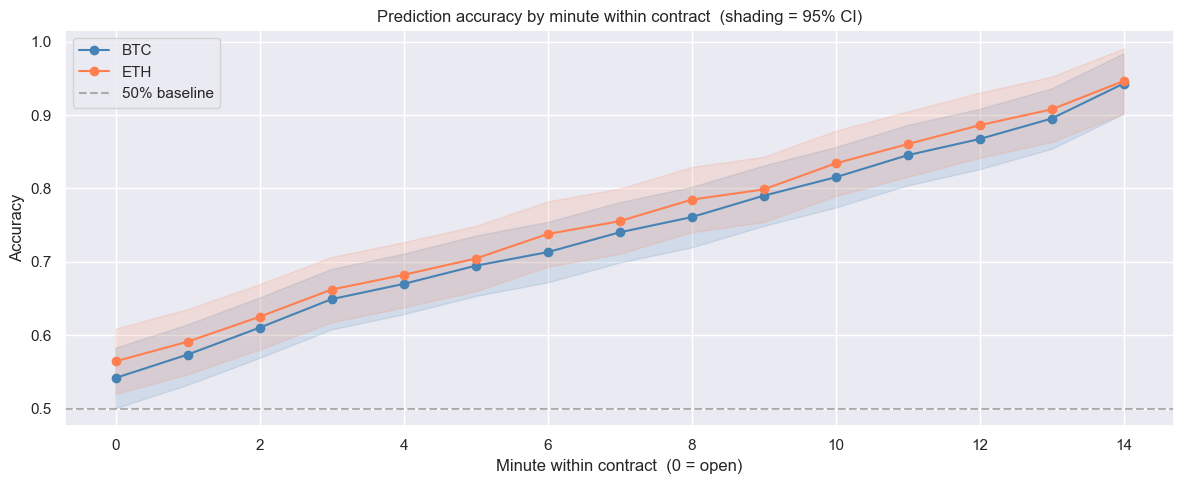

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))

for name, df, color in [('BTC', btc, 'steelblue'), ('ETH', eth, 'coral')]:
    valid = df[df['Correct?'].notna()].copy()
    valid['correct_bin'] = (valid['Correct?'] == 'Correct').astype(int)
    acc = valid.groupby('minute_in_contract')['correct_bin'].agg(['mean', 'count'])

    ax.plot(acc.index, acc['mean'], 'o-', color=color, label=name, ms=6, lw=1.5)
    ax.fill_between(
        acc.index,
        acc['mean'] - 1.96 / np.sqrt(acc['count']),
        acc['mean'] + 1.96 / np.sqrt(acc['count']),
        alpha=0.15, color=color
    )

ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='50% baseline')
ax.set_title('Prediction accuracy by minute within contract  (shading = 95% CI)')
ax.set_xlabel('Minute within contract  (0 = open)')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

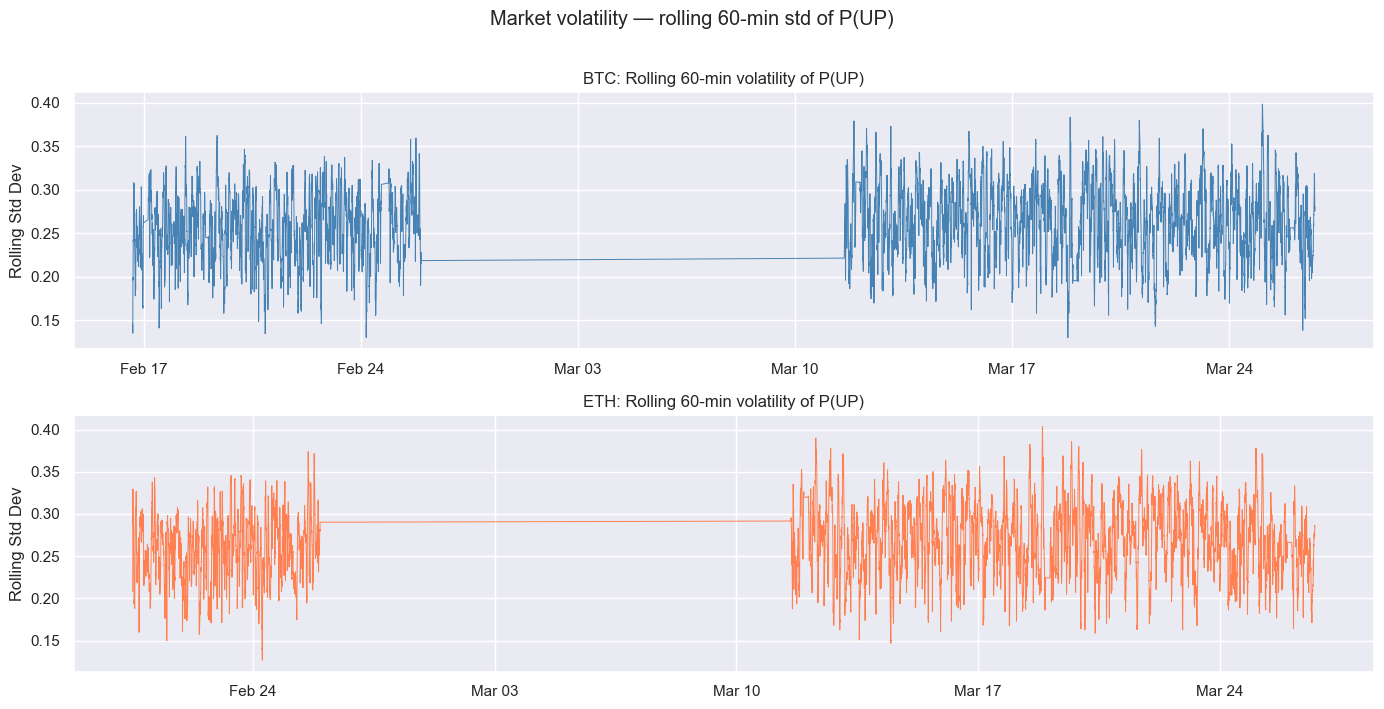

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

for ax, (name, df) in zip(axes, [('BTC', btc), ('ETH', eth)]):
    ts       = df.sort_values('Timestamp').set_index('Timestamp')['P(UP)']
    roll_vol = ts.rolling(60, min_periods=20).std()

    ax.plot(roll_vol.index, roll_vol.values, lw=0.7,
            color='steelblue' if name == 'BTC' else 'coral')
    ax.set_title(f'{name}: Rolling 60-min volatility of P(UP)')
    ax.set_ylabel('Rolling Std Dev')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator())

plt.suptitle('Market volatility — rolling 60-min std of P(UP)', y=1.01)
plt.tight_layout()
plt.show()

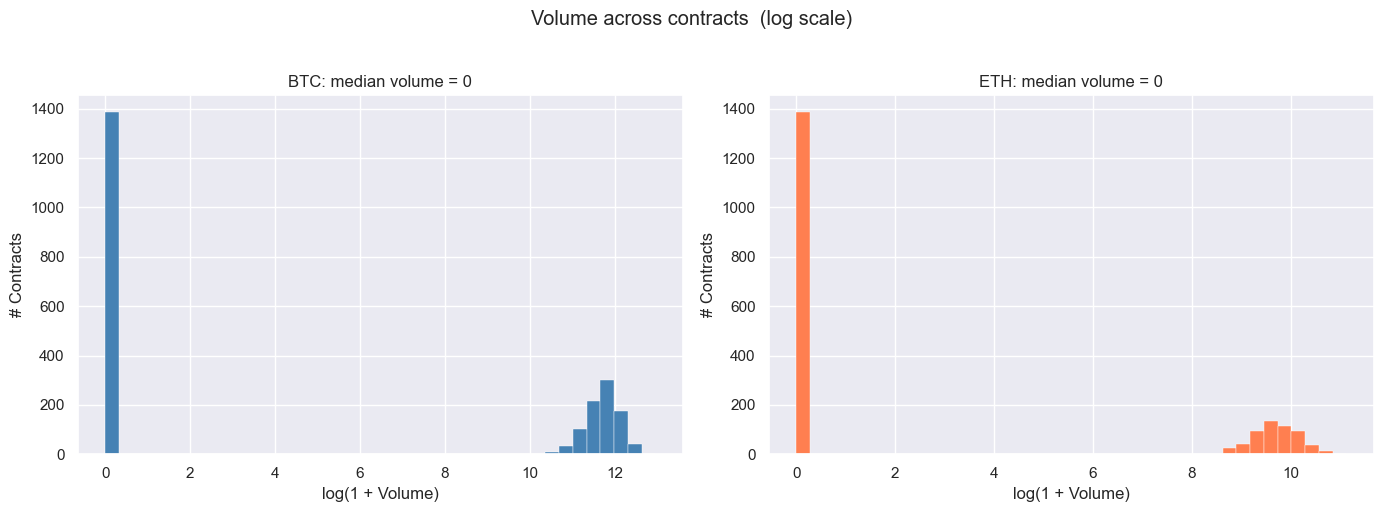

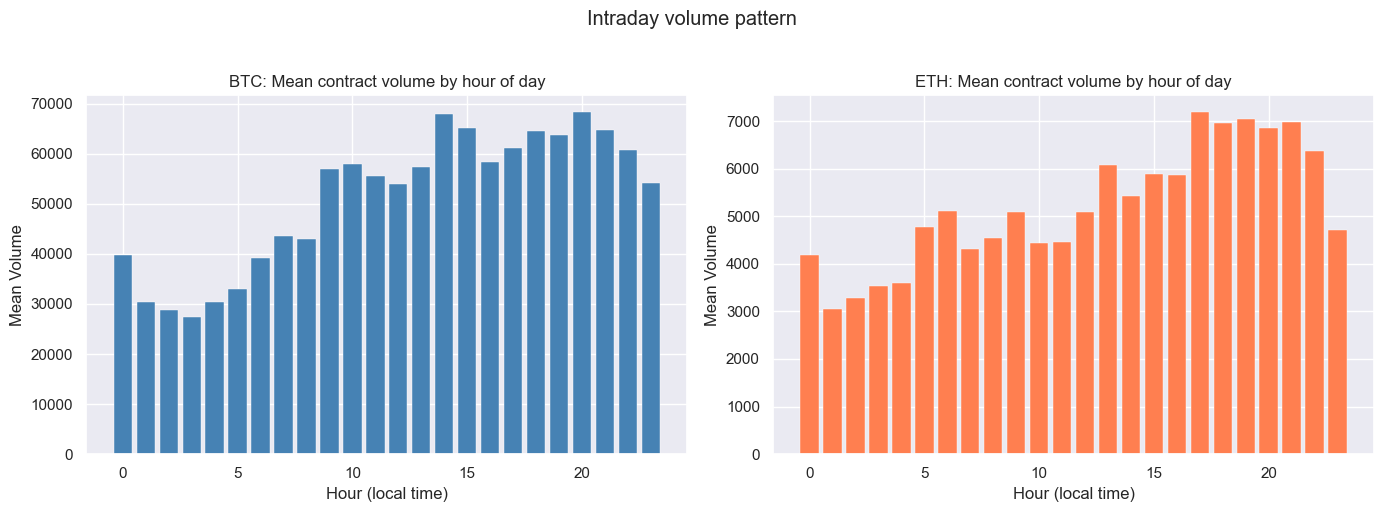

In [22]:
# Volume distribution across contracts + intraday pattern
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, df) in zip(axes, [('BTC', btc), ('ETH', eth)]):
    vol = df[df['minute_in_contract'] == 0]['Volume'].dropna()
    ax.hist(np.log1p(vol), bins=40,
            color='steelblue' if name == 'BTC' else 'coral',
            edgecolor='white', lw=0.3)
    ax.set_title(f'{name}: Contract volume distribution')
    ax.set_xlabel('log(1 + Volume)')
    ax.set_ylabel('# Contracts')
    ax.set_title(f'{name}: median volume = {vol.median():,.0f}')

plt.suptitle('Volume across contracts  (log scale)', y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, df) in zip(axes, [('BTC', btc), ('ETH', eth)]):
    opens = df[df['minute_in_contract'] == 0].copy()
    opens['hour'] = opens['Timestamp'].dt.hour
    vol_by_hour = opens.groupby('hour')['Volume'].mean()
    ax.bar(vol_by_hour.index, vol_by_hour.values,
           color='steelblue' if name == 'BTC' else 'coral',
           edgecolor='white', lw=0.3)
    ax.set_title(f'{name}: Mean contract volume by hour of day')
    ax.set_xlabel('Hour (local time)')
    ax.set_ylabel('Mean Volume')

plt.suptitle('Intraday volume pattern', y=1.02)
plt.tight_layout()
plt.show()

## 3. Signal Construction

Build a contract-level dataset with three engineered features: P(UP) at open, maximum 3-minute momentum, and mean P(UP) over the first 5 minutes. Evaluate two directional signals — a simple threshold baseline and a momentum signal — and close with a calibration check that flags bins where the market is overconfident.

In [23]:
def build_contract_df(df, asset):
    records = []
    for ticker, g in df.groupby('Market Ticker'):
        g = g.sort_values('Timestamp').reset_index(drop=True)

        outcomes = g['Actual Outcome'].dropna()
        actual   = outcomes.iloc[0] if len(outcomes) else None
        target   = 1 if actual == 'UP' else (0 if actual == 'DOWN' else np.nan)

        records.append({
            'ticker':        ticker,
            'asset':         asset,
            'contract_open': g.iloc[0]['Timestamp'],
            'opening_pup':   g.iloc[0]['P(UP)'],
            'max_mom_3min':  g.iloc[:3]['Momentum'].max()  if len(g) >= 3 else np.nan,
            'mean_pup_5min': g.iloc[:5]['P(UP)'].mean()    if len(g) >= 5 else np.nan,
            'actual_outcome': actual,
            'target':         target,
            'volume':         g['Volume'].iloc[0],
            'n_rows':         len(g),
            'is_clean':       g['is_clean'].all(),
        })

    return pd.DataFrame(records)

btc_c = build_contract_df(btc, 'BTC')
eth_c = build_contract_df(eth, 'ETH')

print(f"BTC: {len(btc_c)} contracts | outcomes available: {btc_c['target'].notna().sum()}")
print(f"ETH: {len(eth_c)} contracts | outcomes available: {eth_c['target'].notna().sum()}")
btc_c.head(3)

BTC: 2264 contracts | outcomes available: 2263
ETH: 1943 contracts | outcomes available: 1942


,ticker,asset,contract_open,opening_pup,max_mom_3min,mean_pup_5min,actual_outcome,target,volume,n_rows,is_clean
0,KXBTC15M-26FEB161830-30,BTC,2026-02-16 15:15:00,0.480,0.1434,0.52094,DOWN,0.0,143697.0,15,True
1,KXBTC15M-26FEB161845-45,BTC,2026-02-16 15:30:00,0.535,0.0375,0.60390,UP,1.0,146219.0,15,True
2,KXBTC15M-26FEB161900-00,BTC,2026-02-16 15:45:00,0.495,0.1977,0.66770,UP,1.0,122925.0,15,True


In [24]:
def evaluate_signal(valid, pred_col, label):
    y_true = valid['target'].astype(int)
    y_pred = valid[pred_col].astype(int)
    print(f"\n--- {label}  (n={len(valid)}) ---")
    print(f"  Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
    print(f"  Precision: {precision_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"  Recall:    {recall_score(y_true, y_pred, zero_division=0):.3f}")

for name, contracts in [('BTC', btc_c), ('ETH', eth_c)]:
    valid = contracts[contracts['target'].notna()].copy()
    valid['baseline_pred'] = (valid['opening_pup'] > 0.55).astype(int)
    evaluate_signal(valid, 'baseline_pred', f'{name} — Baseline: P(UP) at open > 0.55')


--- BTC — Baseline: P(UP) at open > 0.55  (n=2263) ---
  Accuracy:  0.519
  Precision: 0.605
  Recall:    0.227

--- ETH — Baseline: P(UP) at open > 0.55  (n=1942) ---
  Accuracy:  0.531
  Precision: 0.591
  Recall:    0.234


In [25]:
for name, contracts in [('BTC', btc_c), ('ETH', eth_c)]:
    valid = contracts[contracts['target'].notna() & contracts['max_mom_3min'].notna()].copy()
    valid['mom_pred'] = (valid['max_mom_3min'] > 0).astype(int)
    evaluate_signal(valid, 'mom_pred', f'{name} — Momentum: max 3-min momentum > 0')


--- BTC — Momentum: max 3-min momentum > 0  (n=2263) ---
  Accuracy:  0.581
  Precision: 0.581
  Recall:    0.707

--- ETH — Momentum: max 3-min momentum > 0  (n=1942) ---
  Accuracy:  0.596
  Precision: 0.582
  Recall:    0.709



BTC calibration (red = overconfident, green = underconfident):
             predicted  realized  count  overconfident
pup_bin                                               
(0.3, 0.4]    0.365063  0.443750    160          False
(0.4, 0.45]   0.428979  0.447183    284          False
(0.45, 0.5]   0.479219  0.510417    768          False
(0.5, 0.55]   0.523065  0.543294    589          False
(0.55, 0.6]   0.574339  0.529183    257          False
(0.6, 0.65]   0.623053  0.699115    113          False
(0.65, 0.7]   0.673654  0.653846     52          False
(0.7, 1.0]    0.752381  0.904762     21          False

ETH calibration (red = overconfident, green = underconfident):
             predicted  realized  count  overconfident
pup_bin                                               
(0.3, 0.4]    0.365825  0.359223    103          False
(0.4, 0.45]   0.435331  0.430025    393          False
(0.45, 0.5]   0.477018  0.476378    508          False
(0.5, 0.55]   0.529070  0.563601    511        

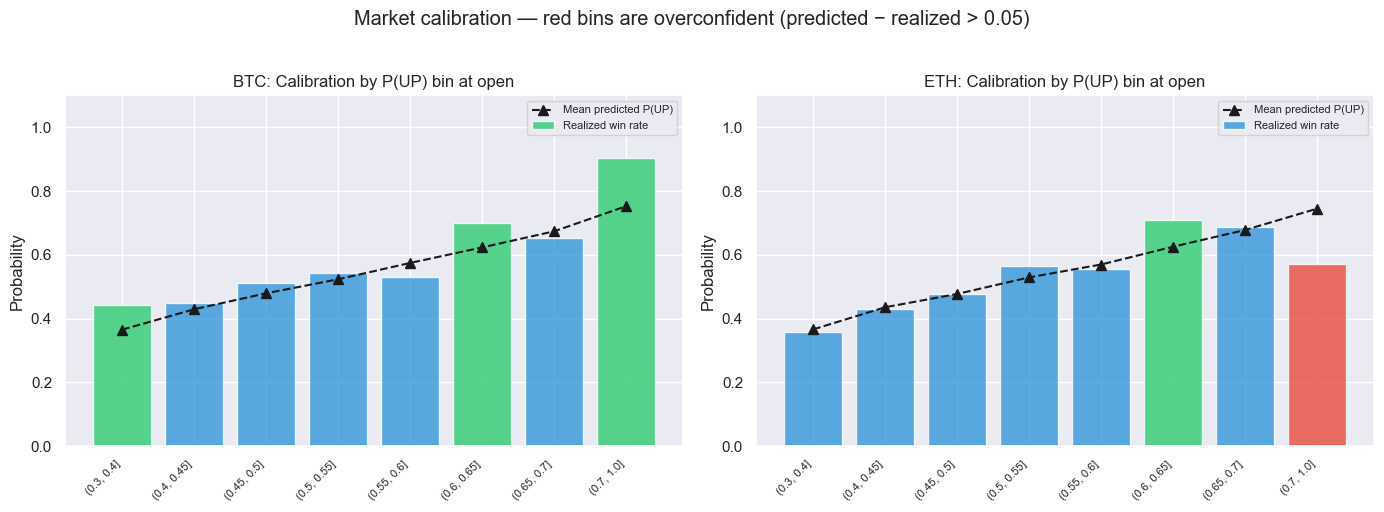

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = [0.30, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 1.0]

for ax, (name, contracts) in zip(axes, [('BTC', btc_c), ('ETH', eth_c)]):
    valid = contracts[contracts['target'].notna()].copy()
    valid['pup_bin'] = pd.cut(valid['opening_pup'], bins=bins)

    calib = valid.groupby('pup_bin', observed=True).agg(
        predicted=('opening_pup', 'mean'),
        realized=('target', 'mean'),
        count=('target', 'count')
    ).dropna()

    calib['overconfident']  = (calib['predicted'] - calib['realized']) > 0.05
    calib['underconfident'] = (calib['realized'] - calib['predicted']) > 0.05

    print(f"\n{name} calibration (red = overconfident, green = underconfident):")
    print(calib[['predicted', 'realized', 'count', 'overconfident']].to_string())

    colors = ['#e74c3c' if oc else ('#2ecc71' if uc else '#3498db')
              for oc, uc in zip(calib['overconfident'], calib['underconfident'])]

    ax.bar(range(len(calib)), calib['realized'], color=colors, alpha=0.8, label='Realized win rate')
    ax.plot(range(len(calib)), calib['predicted'], 'k^--', ms=7, label='Mean predicted P(UP)')
    ax.set_xticks(range(len(calib)))
    ax.set_xticklabels([str(b) for b in calib.index], rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{name}: Calibration by P(UP) bin at open')
    ax.set_ylabel('Probability')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.1)

plt.suptitle('Market calibration — red bins are overconfident (predicted − realized > 0.05)', y=1.02)
plt.tight_layout()
plt.show()

## 4. Backtest Framework

Simulate a long/short strategy using P(UP) at contract open as the sole entry signal. Long if P(UP) > threshold, short if P(DOWN) > threshold, else flat. Binary PnL: +1 correct, −1 wrong. We compare zero vs. 0.1% transaction costs, compute annualised Sharpe (assuming 26 fifteen-minute periods per trading day × 252 days), and scan thresholds 0.50–0.70 to characterise the sensitivity.

In [27]:
def run_backtest(contracts, threshold=0.55, tc=0.0):
    valid = contracts[contracts['target'].notna()].sort_values('contract_open').copy()

    trades = []
    for _, row in valid.iterrows():
        pup = row['opening_pup']
        if pup > threshold:
            direction = 1
        elif (1 - pup) > threshold:
            direction = -1
        else:
            continue  # flat

        outcome  = int(row['target'])
        correct  = (direction == 1 and outcome == 1) or (direction == -1 and outcome == 0)
        raw_pnl  = 1 if correct else -1
        trades.append({'contract_open': row['contract_open'], 'pnl': raw_pnl - tc})

    if not trades:
        return pd.DataFrame(), {}

    df_t = pd.DataFrame(trades)
    df_t['cumulative_pnl'] = df_t['pnl'].cumsum()

    # Annualise: 252 trading days × 26 fifteen-min periods per 6.5-hr day
    periods_per_year = 252 * 26
    mean_ret = df_t['pnl'].mean()
    std_ret  = df_t['pnl'].std()
    sharpe   = mean_ret / std_ret * np.sqrt(periods_per_year) if std_ret > 0 else np.nan

    return df_t, {
        'total_trades': len(df_t),
        'hit_rate':     (df_t['pnl'] > 0).mean(),
        'total_pnl':    df_t['pnl'].sum(),
        'sharpe':       sharpe,
    }


BTC  (TC = 0):
  total_trades: 885
  hit_rate: 0.5898
  total_pnl: 159.0000
  sharpe: 14.7747

ETH  (TC = 0):
  total_trades: 848
  hit_rate: 0.5896
  total_pnl: 152.0000
  sharpe: 14.7391


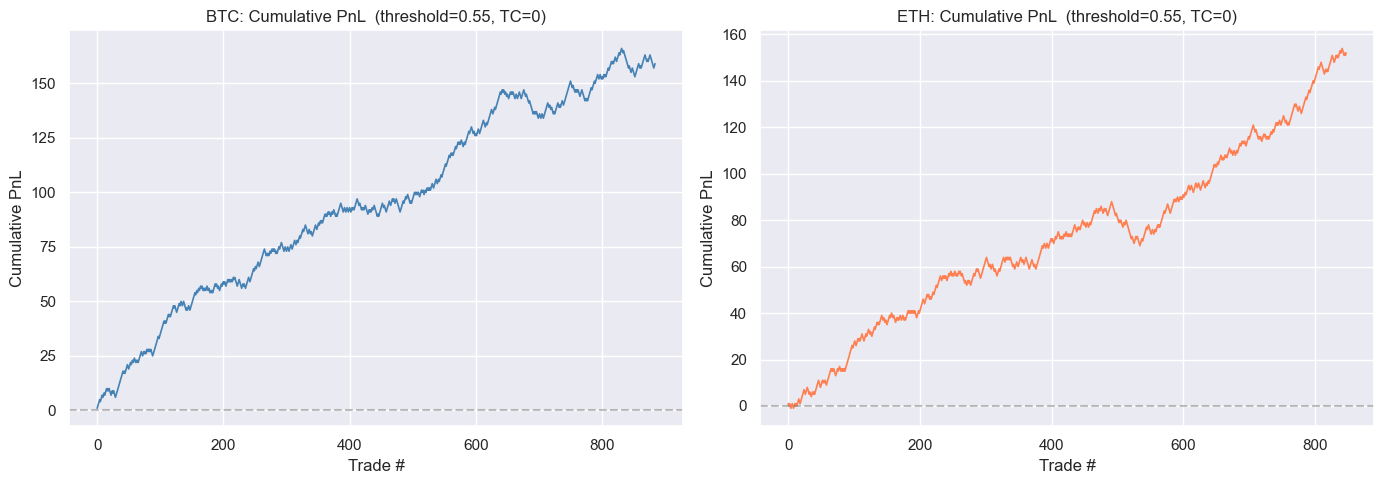

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, contracts) in zip(axes, [('BTC', btc_c), ('ETH', eth_c)]):
    trades_df, s = run_backtest(contracts, threshold=0.55, tc=0.0)
    print(f"\n{name}  (TC = 0):")
    for k, v in s.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

    ax.plot(trades_df['cumulative_pnl'].values, lw=1.2,
            color='steelblue' if name == 'BTC' else 'coral')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{name}: Cumulative PnL  (threshold=0.55, TC=0)')
    ax.set_xlabel('Trade #')
    ax.set_ylabel('Cumulative PnL')

plt.tight_layout()
plt.show()


BTC  (TC = 0.1% per trade):
  total_trades: 885
  hit_rate: 0.5898
  total_pnl: 158.1150
  sharpe: 14.6925

ETH  (TC = 0.1% per trade):
  total_trades: 848
  hit_rate: 0.5896
  total_pnl: 151.1520
  sharpe: 14.6568


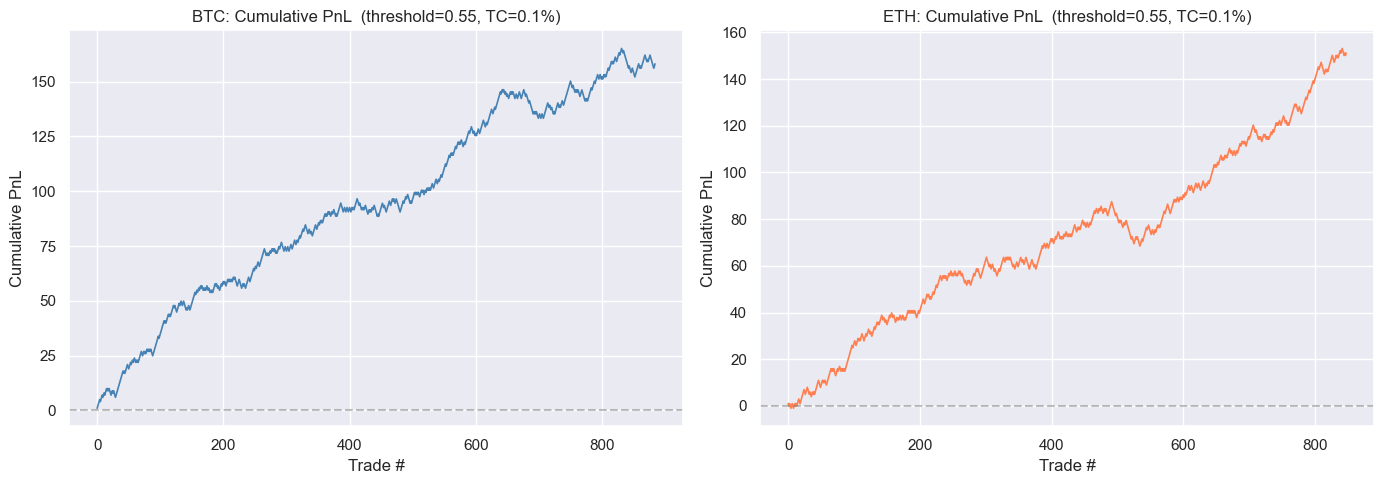

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, contracts) in zip(axes, [('BTC', btc_c), ('ETH', eth_c)]):
    trades_df, s = run_backtest(contracts, threshold=0.55, tc=0.001)
    print(f"\n{name}  (TC = 0.1% per trade):")
    for k, v in s.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

    ax.plot(trades_df['cumulative_pnl'].values, lw=1.2,
            color='steelblue' if name == 'BTC' else 'coral')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{name}: Cumulative PnL  (threshold=0.55, TC=0.1%)')
    ax.set_xlabel('Trade #')
    ax.set_ylabel('Cumulative PnL')

plt.tight_layout()
plt.show()

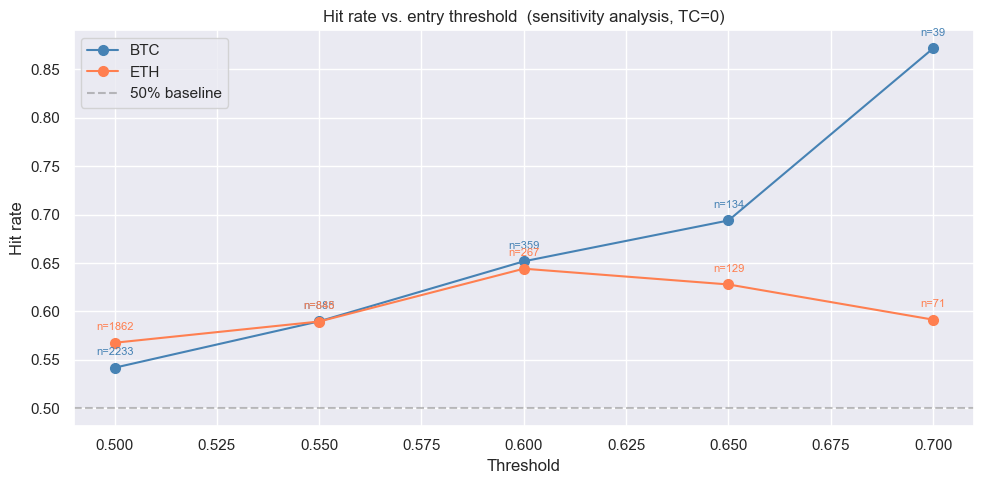

In [30]:
thresholds = np.arange(0.50, 0.71, 0.05)
fig, ax = plt.subplots(figsize=(10, 5))

for name, contracts, color in [('BTC', btc_c, 'steelblue'), ('ETH', eth_c, 'coral')]:
    hit_rates, trade_counts = [], []
    for thr in thresholds:
        _, s = run_backtest(contracts, threshold=thr)
        hit_rates.append(s.get('hit_rate', np.nan))
        trade_counts.append(s.get('total_trades', 0))

    ax.plot(thresholds, hit_rates, 'o-', color=color, label=name, ms=7)
    for thr, hr, n in zip(thresholds, hit_rates, trade_counts):
        if not np.isnan(hr):
            ax.annotate(f'n={n}', (thr, hr), textcoords='offset points',
                        xytext=(0, 9), ha='center', fontsize=8, color=color)

ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='50% baseline')
ax.set_title('Hit rate vs. entry threshold  (sensitivity analysis, TC=0)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Hit rate')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Cross-Asset Analysis

Merge BTC and ETH contract-level data on contract open time to test cross-asset predictability. We report P(UP) correlation between the two assets, test whether each asset's opening probability predicts the other's outcome (point-biserial r + p-value), and fit a logistic regression predicting BTC outcome from all four features.

In [31]:
btc_m = btc_c.copy()
eth_m = eth_c.copy()
btc_m['open_key'] = btc_m['contract_open'].dt.floor('min')
eth_m['open_key'] = eth_m['contract_open'].dt.floor('min')

merged = pd.merge(
    btc_m[['open_key', 'opening_pup', 'max_mom_3min', 'mean_pup_5min', 'target', 'volume', 'is_clean']],
    eth_m[['open_key', 'opening_pup', 'max_mom_3min', 'mean_pup_5min', 'target', 'volume', 'is_clean']],
    on='open_key', suffixes=('_btc', '_eth')
)

valid_merged = merged[merged['target_btc'].notna() & merged['target_eth'].notna()].copy()
print(f"Total matched contract pairs: {len(merged)}")
print(f"Both outcomes known:          {len(valid_merged)}")
valid_merged.head(3)

Total matched contract pairs: 1920
Both outcomes known:          1919


,open_key,opening_pup_btc,max_mom_3min_btc,mean_pup_5min_btc,target_btc,volume_btc,is_clean_btc,opening_pup_eth,max_mom_3min_eth,mean_pup_5min_eth,target_eth,volume_eth,is_clean_eth
0,2026-02-20 12:15:00,0.425,0.000,0.34676,0.0,104405.0,True,0.245,0.0050,0.24900,0.0,8119.0,True
1,2026-02-20 12:30:00,0.480,0.093,0.55992,1.0,87215.0,True,0.525,0.0542,0.55034,1.0,6975.0,True
2,2026-02-20 12:45:00,0.540,0.020,0.52666,1.0,224813.0,True,0.540,0.0558,0.57790,1.0,22593.0,True


P(UP) correlation (BTC vs ETH at open): 0.4657

ETH P(UP) → BTC outcome: point-biserial r=0.1476,  p=0.0000
BTC P(UP) → ETH outcome: point-biserial r=0.1201, p=0.0000


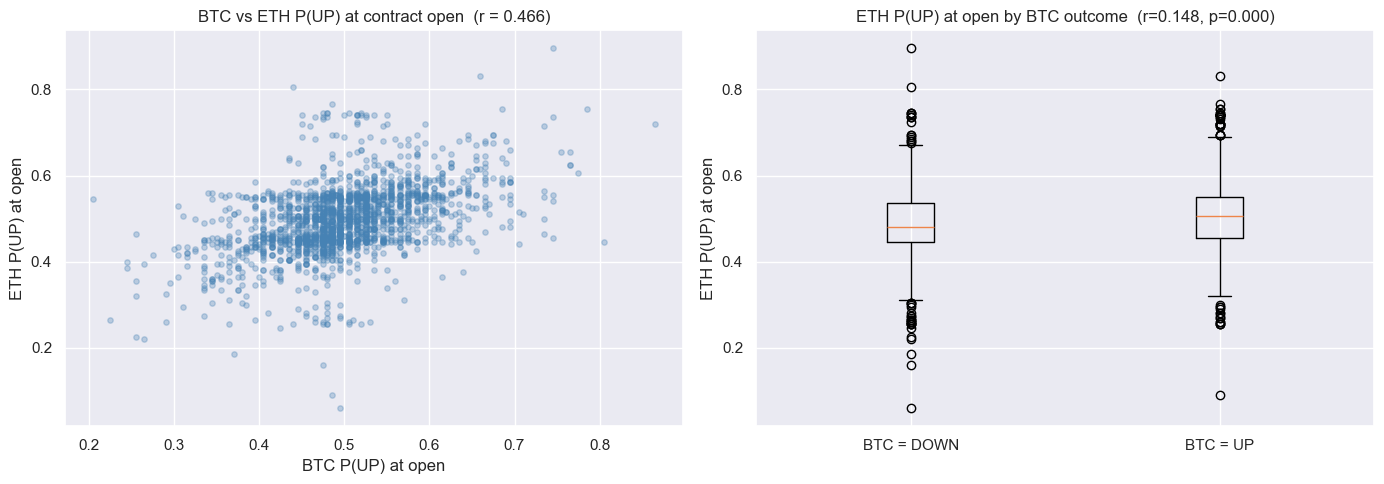

In [32]:
corr_pup = valid_merged['opening_pup_btc'].corr(valid_merged['opening_pup_eth'])
print(f"P(UP) correlation (BTC vs ETH at open): {corr_pup:.4f}")

r_cross,  p_cross  = stats.pointbiserialr(valid_merged['target_btc'], valid_merged['opening_pup_eth'])
r_cross2, p_cross2 = stats.pointbiserialr(valid_merged['target_eth'], valid_merged['opening_pup_btc'])
print(f"\nETH P(UP) → BTC outcome: point-biserial r={r_cross:.4f},  p={p_cross:.4f}")
print(f"BTC P(UP) → ETH outcome: point-biserial r={r_cross2:.4f}, p={p_cross2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(valid_merged['opening_pup_btc'], valid_merged['opening_pup_eth'],
                alpha=0.3, s=15, color='steelblue')
axes[0].set_xlabel('BTC P(UP) at open')
axes[0].set_ylabel('ETH P(UP) at open')
axes[0].set_title(f'BTC vs ETH P(UP) at contract open  (r = {corr_pup:.3f})')

axes[1].boxplot(
    [valid_merged[valid_merged['target_btc'] == 0]['opening_pup_eth'].dropna(),
     valid_merged[valid_merged['target_btc'] == 1]['opening_pup_eth'].dropna()],
    labels=['BTC = DOWN', 'BTC = UP']
)
axes[1].set_title(f'ETH P(UP) at open by BTC outcome  (r={r_cross:.3f}, p={p_cross:.3f})')
axes[1].set_ylabel('ETH P(UP) at open')

plt.tight_layout()
plt.show()

In [33]:
features = ['opening_pup_btc', 'opening_pup_eth', 'max_mom_3min_btc', 'max_mom_3min_eth']
reg_df = valid_merged[features + ['target_btc']].dropna()

X = reg_df[features]
y = reg_df['target_btc'].astype(int)

print(f"Logistic regression sample: {len(reg_df)} contracts")
print(f"Base rate (% UP): {y.mean():.3f}\n")

# Statsmodels for coefficients + p-values
X_sm = sm.add_constant(X)
result = sm.Logit(y, X_sm).fit(disp=0)
print(result.summary2())

# Sklearn cross-validated accuracy
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=500))
cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
print(f"\n5-fold CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Majority-class baseline: {max(y.mean(), 1 - y.mean()):.3f}")

Logistic regression sample: 1919 contracts
Base rate (% UP): 0.525

                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: target_btc       Pseudo R-squared: 0.055     
Date:               2026-04-15 23:31 AIC:              2520.7441 
No. Observations:   1919             BIC:              2548.5419 
Df Model:           4                Log-Likelihood:   -1255.4   
Df Residuals:       1914             LL-Null:          -1327.8   
Converged:          1.0000           LLR p-value:      2.5828e-30
No. Iterations:     5.0000           Scale:            1.0000    
-----------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------
const             -2.8853   0.3730 -7.7362 0.0000 -3.6163 -2.1543
opening_pup_btc    1.6509   0.7724  2.1374 0.0326  0.1370  3.1647
opening_pup_eth    3.5542   0.7540